In [1]:
# ============================================================
# Fake News Detection using Machine Learning
# WELFake Dataset | NLP Classification
# Models: Naive Bayes, SVM, Logistic Regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:
# ============================================================
# STEP 1: LOAD DATASET
# ============================================================

df = pd.read_csv('WELFake_Dataset.csv')

print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

=== Dataset Overview ===
Shape: (72134, 4)

Columns: ['Unnamed: 0', 'title', 'text', 'label']

First 5 rows:
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Missing values:
Unnamed: 0      0


In [3]:
# ============================================================
# STEP 2: DATA PREPROCESSING
# ============================================================

# Drop rows with missing title or text
df.dropna(subset=['title', 'text'], inplace=True)

# Combine title and text into one field
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Reset index
df.reset_index(drop=True, inplace=True)

print(f"\nAfter cleaning - Shape: {df.shape}")

# ---- Text Cleaning Function ----
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and stem
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

print("\nCleaning text... (this may take a few minutes)")
df['clean_content'] = df['content'].apply(clean_text)
print("Text cleaning complete.")


After cleaning - Shape: (71537, 5)

Cleaning text... (this may take a few minutes)
Text cleaning complete.



=== Exploratory Data Analysis ===

Label Counts:
label
1    36509
0    35028
Name: count, dtype: int64
0 = Real News, 1 = Fake News


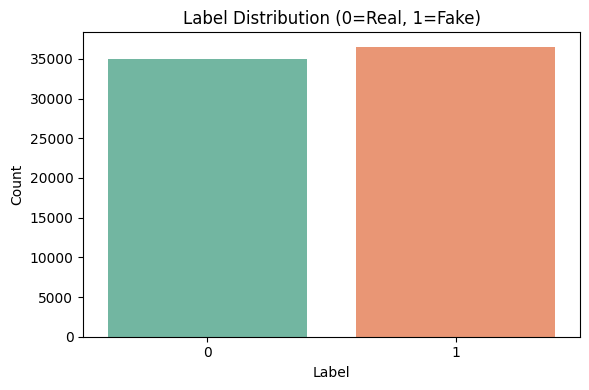

Saved: label_distribution.png


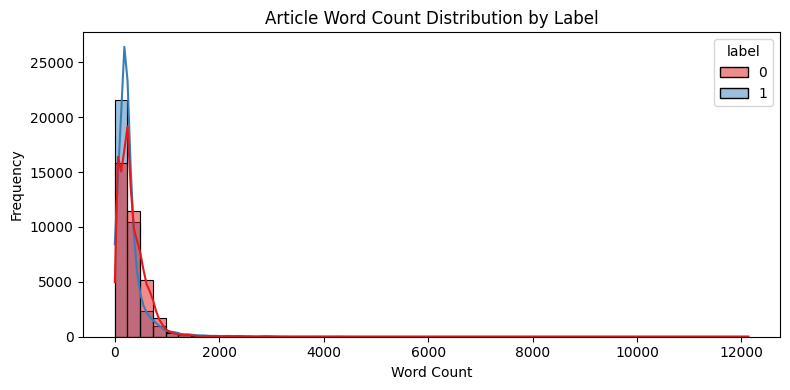

Saved: word_count_distribution.png


In [4]:
# ============================================================
# STEP 3: EXPLORATORY DATA ANALYSIS
# ============================================================

print("\n=== Exploratory Data Analysis ===")

# Label distribution
label_counts = df['label'].value_counts()
print(f"\nLabel Counts:\n{label_counts}")
print(f"0 = Real News, 1 = Fake News")

# Plot label distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Label Distribution (0=Real, 1=Fake)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print("Saved: label_distribution.png")

# Article length distribution
df['content_length'] = df['clean_content'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='content_length', hue='label', bins=50, kde=True, palette='Set1')
plt.title('Article Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150)
plt.show()
print("Saved: word_count_distribution.png")

In [5]:
# ============================================================
# STEP 4: FEATURE EXTRACTION — TF-IDF
# ============================================================

X = df['clean_content']
y = df['label']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")
print(f"TF-IDF Matrix Shape (Test) : {X_test_tfidf.shape}")

# ============================================================
# STEP 5: MODEL TRAINING
# ============================================================

# ---- Model 1: Naive Bayes ----
print("\n=== Training Naive Bayes ===")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
print("Naive Bayes training complete.")

# ---- Model 2: Support Vector Machine ----
print("\n=== Training SVM (LinearSVC) ===")
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)
print("SVM training complete.")

# ---- Model 3: Logistic Regression ----
print("\n=== Training Logistic Regression ===")
lr_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                               random_state=42, n_jobs=-1)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
print("Logistic Regression training complete.")


Training samples : 57229
Testing samples  : 14308

TF-IDF Matrix Shape (Train): (57229, 50000)
TF-IDF Matrix Shape (Test) : (14308, 50000)

=== Training Naive Bayes ===
Naive Bayes training complete.

=== Training SVM (LinearSVC) ===
SVM training complete.

=== Training Logistic Regression ===
Logistic Regression training complete.


In [6]:
# ============================================================
# STEP 6: EVALUATION
# ============================================================

def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred,
                                target_names=['Real (0)', 'Fake (1)']))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

results = []
results.append(evaluate_model("Naive Bayes",          y_test, nb_pred))
results.append(evaluate_model("SVM (LinearSVC)",      y_test, svm_pred))
results.append(evaluate_model("Logistic Regression",  y_test, lr_pred))


  Model: Naive Bayes
  Accuracy  : 0.8971  (89.71%)
  Precision : 0.8976
  Recall    : 0.8971
  F1-Score  : 0.8970

Classification Report:

              precision    recall  f1-score   support

    Real (0)       0.91      0.87      0.89      7006
    Fake (1)       0.88      0.92      0.90      7302

    accuracy                           0.90     14308
   macro avg       0.90      0.90      0.90     14308
weighted avg       0.90      0.90      0.90     14308


  Model: SVM (LinearSVC)
  Accuracy  : 0.9776  (97.76%)
  Precision : 0.9777
  Recall    : 0.9776
  F1-Score  : 0.9776

Classification Report:

              precision    recall  f1-score   support

    Real (0)       0.98      0.97      0.98      7006
    Fake (1)       0.97      0.98      0.98      7302

    accuracy                           0.98     14308
   macro avg       0.98      0.98      0.98     14308
weighted avg       0.98      0.98      0.98     14308


  Model: Logistic Regression
  Accuracy  : 0.9636  (96.36%)

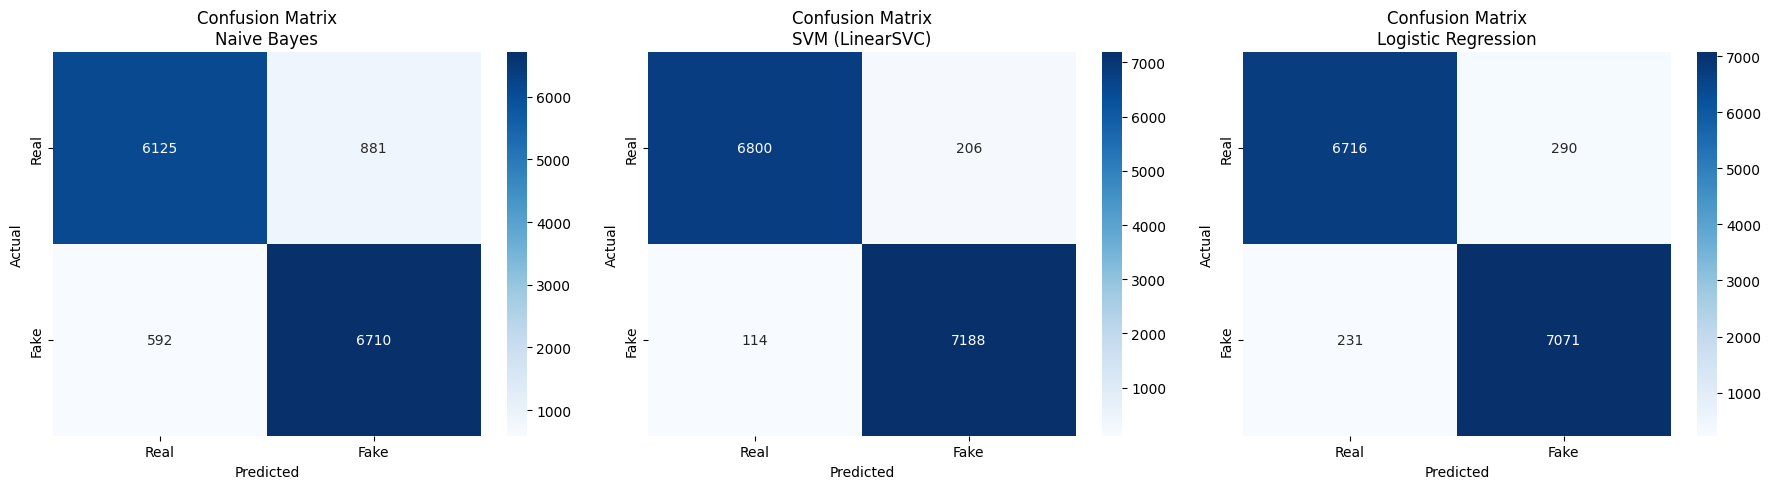


Saved: confusion_matrices.png

=== Model Comparison Summary ===
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes            0.8971     0.8976  0.8971    0.8970
SVM (LinearSVC)        0.9776     0.9777  0.9776    0.9776
Logistic Regression    0.9636     0.9636  0.9636    0.9636


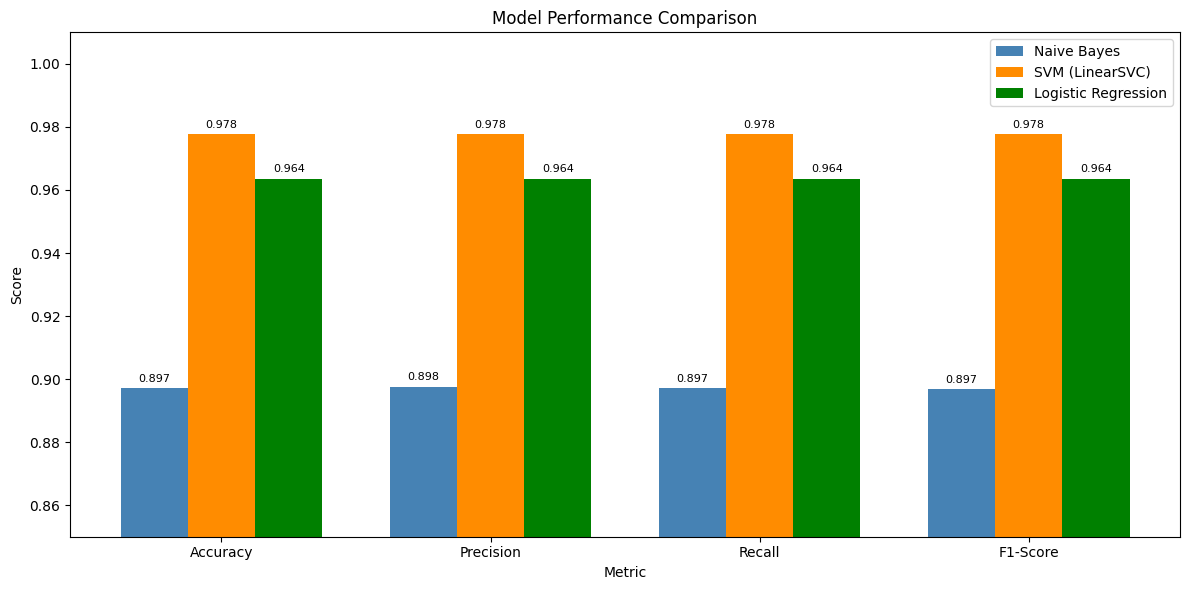

Saved: model_comparison.png

  BEST MODEL: SVM (LinearSVC)
  F1-Score  : 0.9776
  Accuracy  : 0.9776

=== Sample Predictions (Logistic Regression) ===

Text   : Scientists discover new vaccine that eliminates cancer in clinical trials.
Prediction : FAKE

Text   : SHOCKING: President secretly replaced by alien clone, insiders reveal.
Prediction : FAKE

Text   : Federal Reserve raises interest rates by 0.25 percent amid inflation concerns.
Prediction : FAKE

Text   : NASA confirms moon is made of cheese after secret mission footage leaked.
Prediction : FAKE

=== Pipeline Complete ===


In [7]:
# ============================================================
# STEP 7: CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ("Naive Bayes",         nb_pred),
    ("SVM (LinearSVC)",     svm_pred),
    ("Logistic Regression", lr_pred),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("\nSaved: confusion_matrices.png")

# ============================================================
# STEP 8: MODEL COMPARISON TABLE & CHART
# ============================================================

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)

print("\n=== Model Comparison Summary ===")
print(results_df.round(4).to_string())

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, results_df.loc['Naive Bayes', metrics],
               width, label='Naive Bayes', color='steelblue')
bars2 = ax.bar(x,         results_df.loc['SVM (LinearSVC)', metrics],
               width, label='SVM (LinearSVC)', color='darkorange')
bars3 = ax.bar(x + width, results_df.loc['Logistic Regression', metrics],
               width, label='Logistic Regression', color='green')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.01)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars3, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Saved: model_comparison.png")

# ============================================================
# STEP 9: BEST MODEL IDENTIFICATION
# ============================================================

best_model_name = results_df['F1-Score'].idxmax()
best_f1         = results_df['F1-Score'].max()
best_acc        = results_df.loc[best_model_name, 'Accuracy']

print(f"\n{'='*50}")
print(f"  BEST MODEL: {best_model_name}")
print(f"  F1-Score  : {best_f1:.4f}")
print(f"  Accuracy  : {best_acc:.4f}")
print(f"{'='*50}")

# ============================================================
# STEP 10: SAMPLE PREDICTION (Optional Test)
# ============================================================

print("\n=== Sample Predictions (Logistic Regression) ===")

sample_texts = [
    "Scientists discover new vaccine that eliminates cancer in clinical trials.",
    "SHOCKING: President secretly replaced by alien clone, insiders reveal.",
    "Federal Reserve raises interest rates by 0.25 percent amid inflation concerns.",
    "NASA confirms moon is made of cheese after secret mission footage leaked."
]

sample_cleaned = [clean_text(t) for t in sample_texts]
sample_tfidf   = tfidf.transform(sample_cleaned)
sample_preds   = lr_model.predict(sample_tfidf)

for text, pred in zip(sample_texts, sample_preds):
    label = "FAKE" if pred == 1 else "REAL"
    print(f"\nText   : {text}")
    print(f"Prediction : {label}")

print("\n=== Pipeline Complete ===")